<a href="https://colab.research.google.com/github/cemcereb/Predicting-Urban-Benzene-Concentration-Using-IoT-Gas-Sensor-Arrays/blob/main/air_quality_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UCI Air Quality Sensor Dataset — ML Project
**Predicting Benzene Concentration from Metal Oxide Gas Sensor Array**

---

**Dataset:** UCI Air Quality (ID: 360)  
**Task:** Regression — Predict benzene concentration (C6H6) in µg/m³  


### Project Structure
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Model Development & Evaluation
5. Interpretability & Feature Importance
6. Business Insights & Conclusions

---
## 1. Setup & Data Loading

In [ ]:
!pip install ucimlrepo --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import KNNImputer
from sklearn.inspection import permutation_importance

#Dataset
from ucimlrepo import fetch_ucirepo

ACCENT = '#2196F3'

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [ ]:
print('Fetching UCI Air Quality dataset (ID=360)...')
dataset = fetch_ucirepo(id=360)

# Combine features and targets into one DataFrame for easier EDA
df_raw = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

print(f'Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head()

Fetching UCI Air Quality dataset (ID=360)...
Dataset loaded: 9357 rows × 15 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [ ]:
# Data Inspection
print('─── Column Names ───')
print(df_raw.columns.tolist())
print()
print('─── Data Types ───')
print(df_raw.dtypes)
print()
print('─── Basic Statistics ───')
df_raw.describe()

─── Column Names ───
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

─── Data Types ───
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)        int64
NMHC(GT)           int64
C6H6(GT)         float64
PT08.S2(NMHC)      int64
NOx(GT)            int64
PT08.S3(NOx)       int64
NO2(GT)            int64
PT08.S4(NO2)       int64
PT08.S5(O3)        int64
T                float64
RH               float64
AH               float64
dtype: object

─── Basic Statistics ───


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


### 1.1 Column Reference

| Column | Description | Type |
|--------|------------|------|
| `Date`, `Time` | Timestamp | Temporal |
| `CO(GT)` | Ground truth CO concentration (mg/m³) | Target (alt) |
| `PT08.S1(CO)` | Tin oxide sensor — nominally targets CO | Sensor |
| `NMHC(GT)` | Non-methanic hydrocarbons (>90% missing) | Drop |
| `C6H6(GT)` | **Benzene concentration µg/m³ — our target** | **Target** |
| `PT08.S2(NMHC)` | Titania sensor — nominally targets NMHC | Sensor |
| `NOx(GT)` | Ground truth NOx (ppb) | Feature |
| `PT08.S3(NOx)` | Tungsten oxide sensor — nominally targets NOx | Sensor |
| `NO2(GT)` | Ground truth NO2 (µg/m³) | Feature |
| `PT08.S4(NO2)` | Tungsten oxide sensor — nominally targets NO2 | Sensor |
| `PT08.S5(O3)` | Indium oxide sensor — nominally targets O3 | Sensor |
| `T` | Temperature (°C) | Environmental |
| `RH` | Relative Humidity (%) | Environmental |
| `AH` | Absolute Humidity | Environmental |

> **Important:** Missing values are coded as -200, NOT NaN. We must handle this before any analysis.

---
## 2. Exploratory Data Analysis (EDA)

In [ ]:
# Replace missing values with NaN
df = df_raw.copy()
df.replace(-200, np.nan, inplace=True)

df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)



### Plot 1 — Missing Value Heatmap

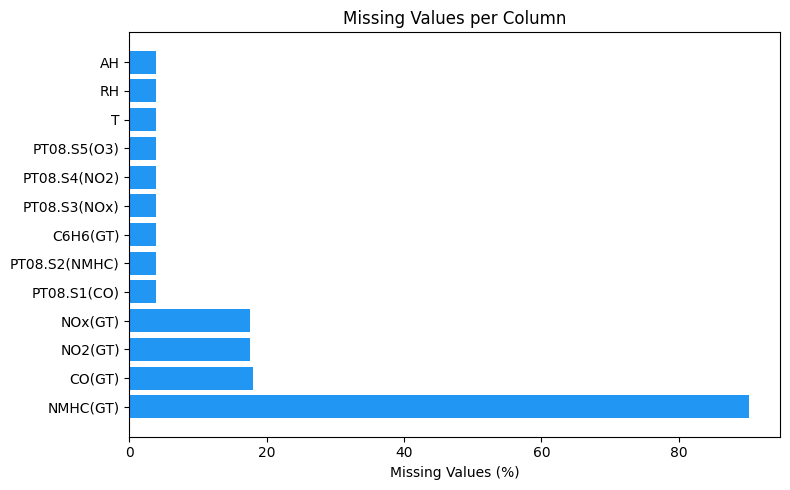


Missing value summary:
NMHC(GT)         90.2
CO(GT)           18.0
NO2(GT)          17.5
NOx(GT)          17.5
PT08.S1(CO)       3.9
PT08.S2(NMHC)     3.9
C6H6(GT)          3.9
PT08.S3(NOx)      3.9
PT08.S4(NO2)      3.9
PT08.S5(O3)       3.9
T                 3.9
RH                3.9
AH                3.9


In [ ]:
# Missing Data Analysis
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
missing_pct = df[numeric_cols].isnull().mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing_pct.index, missing_pct.values, color= ACCENT)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values per Column')
plt.tight_layout()
plt.show()



print('\nMissing value summary:')
print(missing_pct[missing_pct > 0].round(1).to_string())

**Insight:** `NMHC(GT)` is missing ~90% of values — this column will be dropped. Other columns have structured, synchronized dropout patterns, suggesting sensor downtime events rather than random missingness. KNN imputation is appropriate for the remaining gaps.

### Plot 2 — Target Variable Distribution (Benzene)

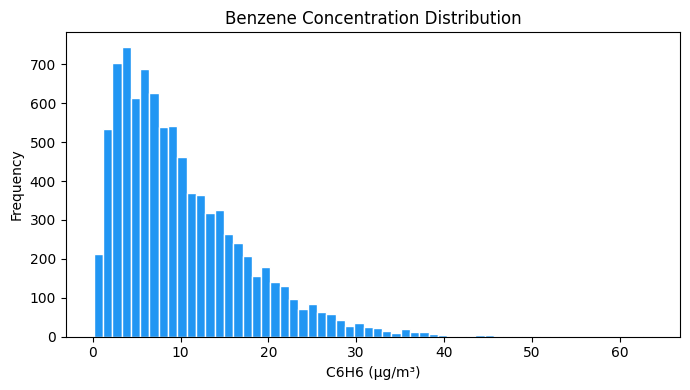

Benzene stats:
  Mean:   10.08 µg/m³
  Median: 8.20 µg/m³
  Std:    7.45
  Skew:   1.36


In [ ]:
# Benzene Distribution
benzene = df['C6H6(GT)'].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(benzene, bins=60, color=ACCENT, edgecolor='white')
ax.set_xlabel('C6H6 (µg/m³)')
ax.set_ylabel('Frequency')
ax.set_title('Benzene Concentration Distribution')
plt.tight_layout()
plt.show()

print(f'Benzene stats:\n  Mean:   {benzene.mean():.2f} µg/m³')
print(f'  Median: {benzene.median():.2f} µg/m³')
print(f'  Std:    {benzene.std():.2f}')
print(f'  Skew:   {benzene.skew():.2f}')

**Insight:** Benzene concentration is **right-skewed** — a small number of high-pollution hours pull the distribution.

### Plot 3 — Time Series: Benzene & Temperature Over the Year

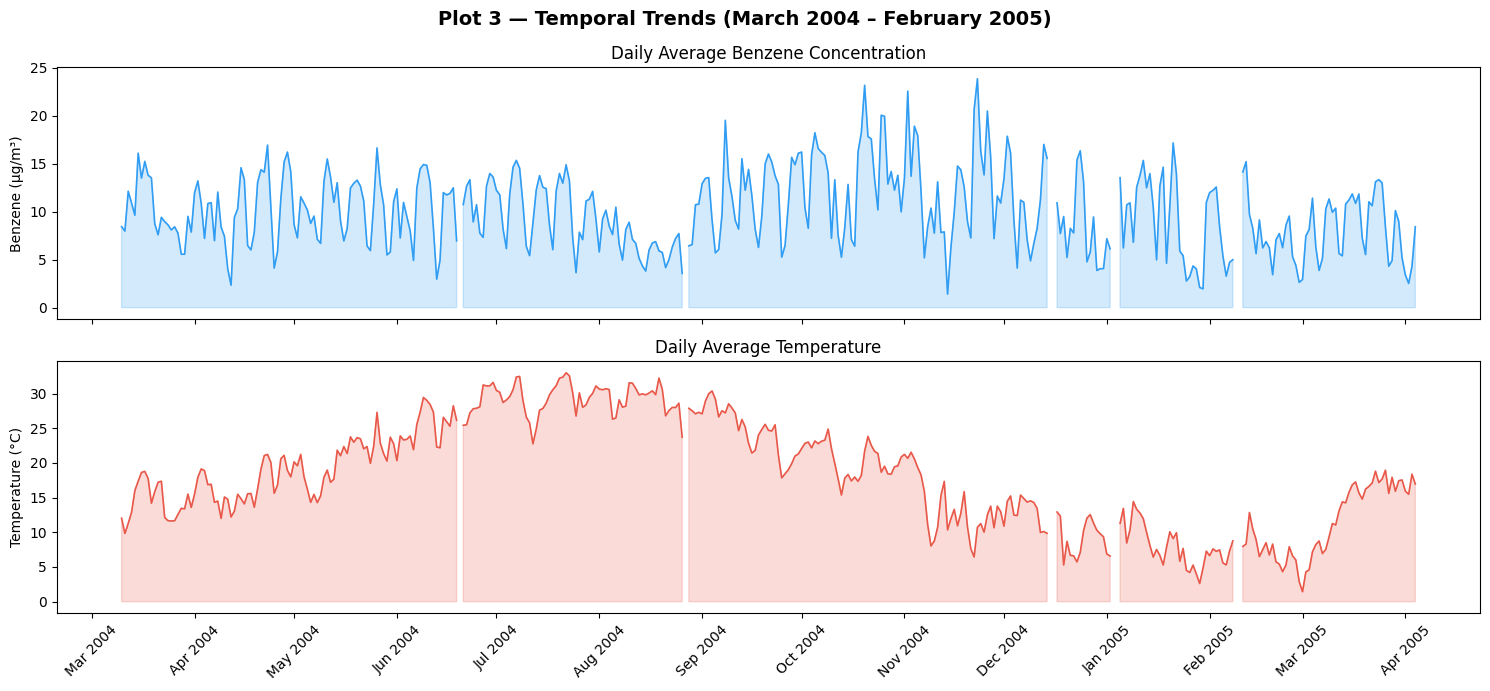

In [ ]:
# Time Series
ts = df[['Datetime', 'C6H6(GT)', 'T']].dropna(subset=['Datetime'])
ts_daily = ts.set_index('Datetime').resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(ts_daily.index, ts_daily['C6H6(GT)'], color=ACCENT, linewidth=1.2, alpha=0.9)
axes[0].fill_between(ts_daily.index, ts_daily['C6H6(GT)'], alpha=0.2, color=ACCENT)
axes[0].set_ylabel('Benzene (µg/m³)')
axes[0].set_title('Daily Average Benzene Concentration')

axes[1].plot(ts_daily.index, ts_daily['T'], color='#e74c3c', linewidth=1.2, alpha=0.9)
axes[1].fill_between(ts_daily.index, ts_daily['T'], alpha=0.2, color='#e74c3c')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Daily Average Temperature')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.suptitle('Plot 3 — Temporal Trends (March 2004 – February 2005)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Benzene levels are **higher in winter months** and lower in summer — opposite to temperature. This is consistent with increased road traffic emissions in cold months and reduced photochemical dispersal. This seasonal pattern means `Month` will be an important engineered feature.

### Plot 4 — Diurnal (Hourly) Patterns

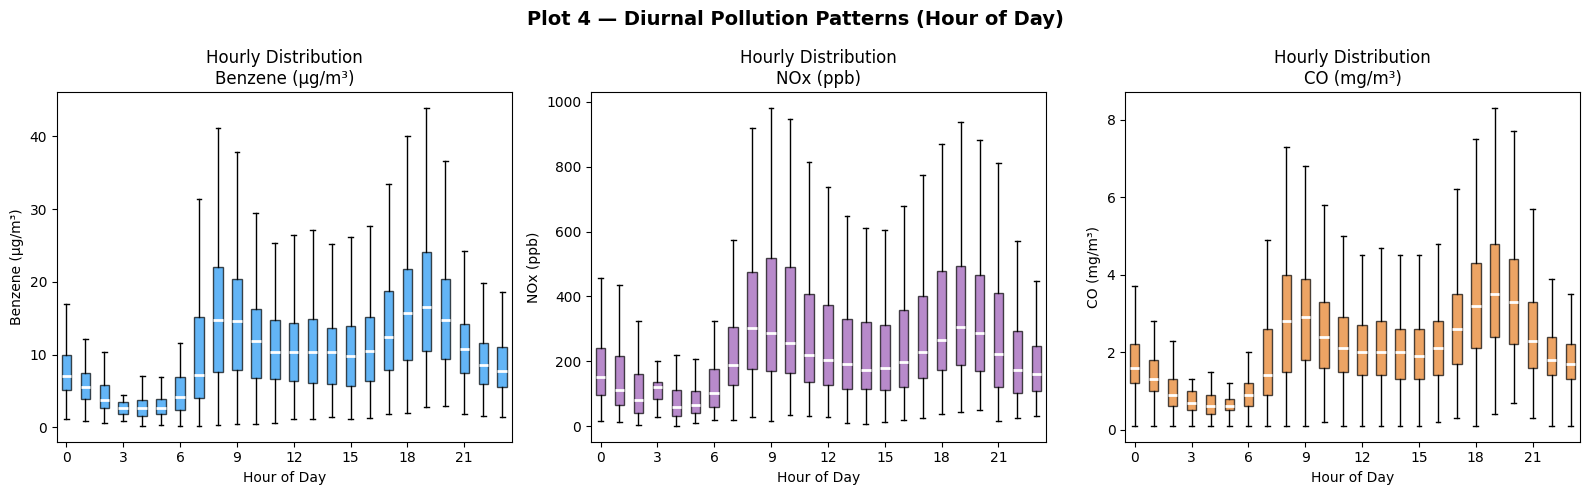

In [ ]:
# Hourly Box Plots (Benzene, NOx, CO)
df['Hour'] = df['Datetime'].dt.hour
hourly = df[['Hour', 'C6H6(GT)', 'NOx(GT)', 'CO(GT)']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pollutants = ['C6H6(GT)', 'NOx(GT)', 'CO(GT)']
titles     = ['Benzene (µg/m³)', 'NOx (ppb)', 'CO (mg/m³)']
colors_p   = [ACCENT, '#9b59b6', '#e67e22']

for ax, col, title, color in zip(axes, pollutants, titles, colors_p):
    hourly_grouped = [hourly[hourly['Hour'] == h][col].values for h in range(24)]
    bp = ax.boxplot(hourly_grouped, patch_artist=True, showfliers=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(title)
    ax.set_title(f'Hourly Distribution\n{title}')
    ax.set_xticks(range(1, 25, 3))
    ax.set_xticklabels(range(0, 24, 3))

plt.suptitle('Plot 4 — Diurnal Pollution Patterns (Hour of Day)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Clear **rush hour peaks** are visible — morning (7–9 AM) and evening (17–20h) — classic traffic-driven pollution signatures. CO and NOx peak sharply, while Benzene shows a similar but smoother profile. This confirms that `Hour` is a strong predictive feature.

### Plot 5 — Correlation Heatmap

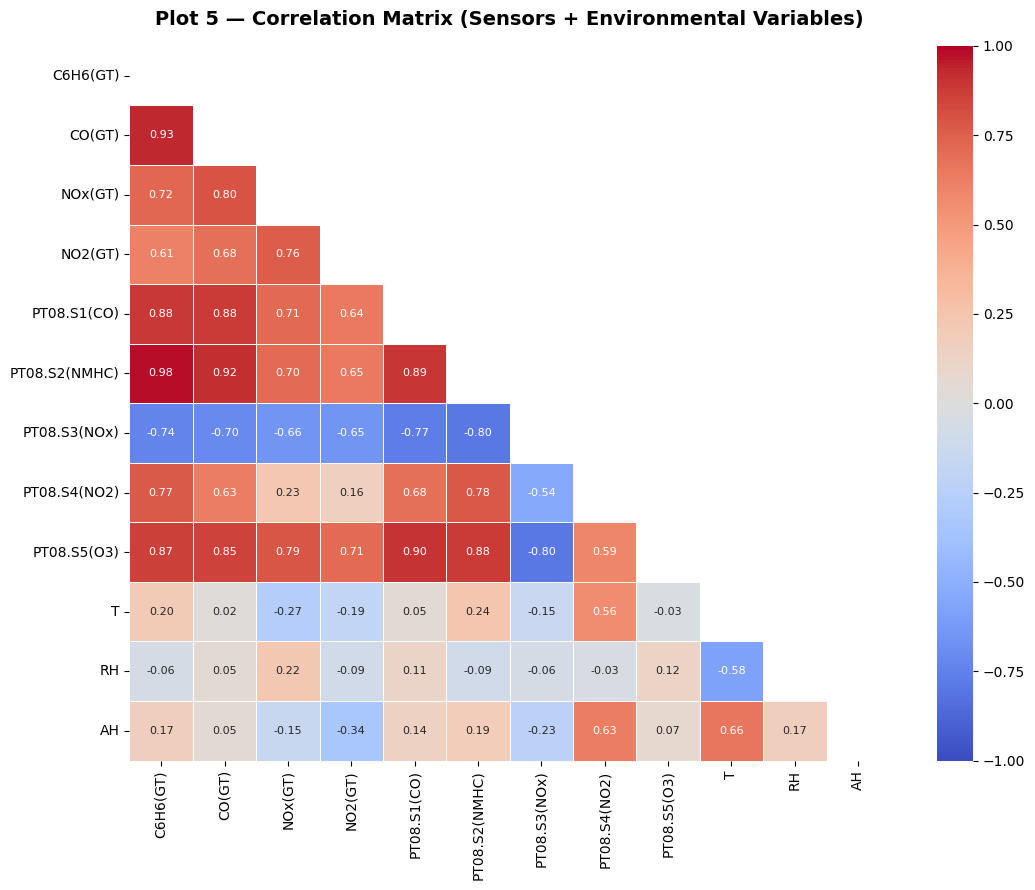

In [ ]:
sensor_cols = [
    'C6H6(GT)', 'CO(GT)', 'NOx(GT)', 'NO2(GT)',
    'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)',
    'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH'
]
corr = df[sensor_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Plot 5 — Correlation Matrix (Sensors + Environmental Variables)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Insight:** Strong cross-correlations between sensor readings confirm **sensor cross-sensitivity** — a known phenomenon in metal oxide arrays. `PT08.S2(NMHC)` has the highest correlation with C6H6 (Benzene, target variable), which makes physical sense as it nominally targets non-methanic hydrocarbons in the same chemical family. Temperature and absolute humidity also correlate strongly, indicating environmental compensation will be important.

### Plot 6 — Sensor vs Benzene Scatter Plots

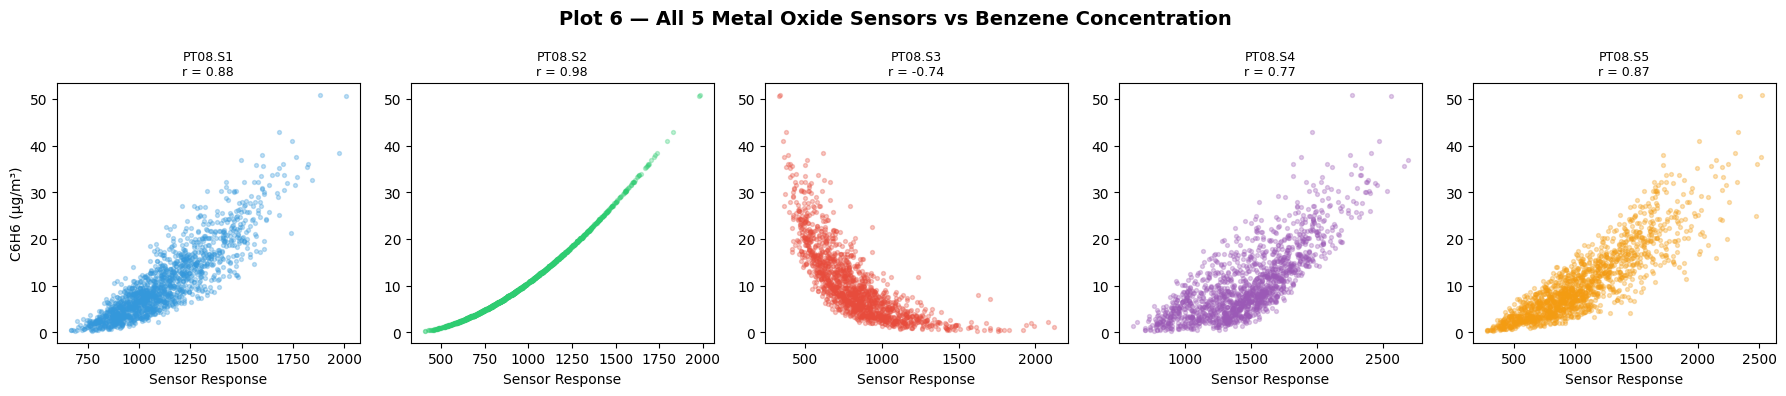

In [ ]:
# Sensor-Target Scatter Plots
sensors = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
scatter_df = df[sensors + ['C6H6(GT)']].dropna()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for ax, sensor, color in zip(axes, sensors, palette):
    sample = scatter_df.sample(min(1500, len(scatter_df)), random_state=42)
    ax.scatter(sample[sensor], sample['C6H6(GT)'],
               alpha=0.3, s=8, color=color)
    # Correlation annotation
    r = scatter_df[sensor].corr(scatter_df['C6H6(GT)'])
    ax.set_title(f'{sensor.split("(")[0]}\nr = {r:.2f}', fontsize=9)
    ax.set_xlabel('Sensor Response')
    if ax == axes[0]:
        ax.set_ylabel('C6H6 (µg/m³)')

plt.suptitle('Plot 6 — All 5 Metal Oxide Sensors vs Benzene Concentration',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** `PT08.S2(NMHC)` shows the strongest and most linear relationship with benzene. `PT08.S3(NOx)` shows an **inverse** relationship — higher NOx sensor response correlates with lower benzene, a classic cross-sensitivity artifact. These relationships motivate including all 5 sensors rather than selecting just one.

### Plot 7 — Monthly Benzene Averages (Seasonality)

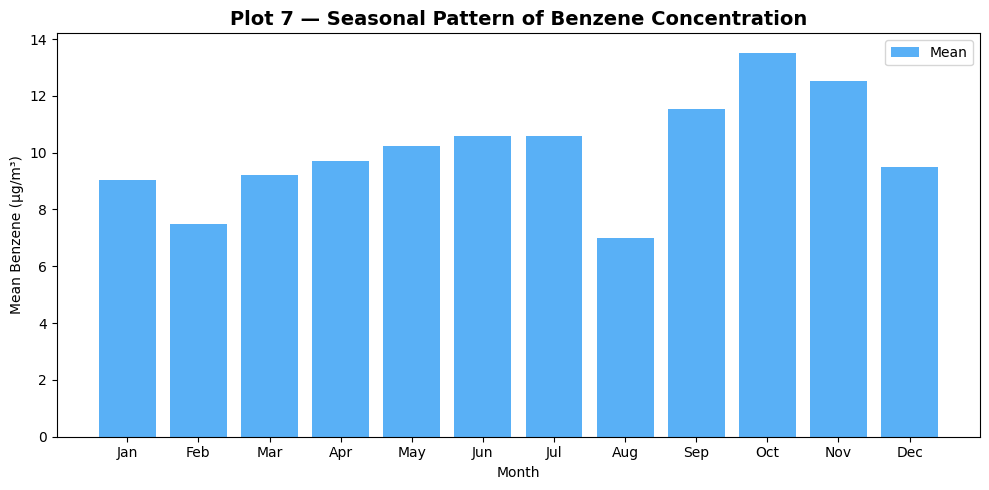

In [ ]:
# Seasonal Benzene Pattern
df['Month'] = df['Datetime'].dt.month
monthly = df.groupby('Month')['C6H6(GT)'].agg(['mean', 'std']).dropna()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
x = monthly.index
ax.bar(x, monthly['mean'], color=ACCENT, alpha=0.75, label='Mean')

ax.set_xticks(x)
ax.set_xticklabels([month_names[m-1] for m in x])
ax.set_xlabel('Month')
ax.set_ylabel('Mean Benzene (µg/m³)')
ax.set_title('Plot 7 — Seasonal Pattern of Benzene Concentration', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** Winter months (Nov–Feb) show significantly elevated benzene levels with wider variance, while summer months (Jun–Aug) are cleaner and more stable. This seasonal effect confirms `Month` as a high-value engineered feature for the model.

---
## 3. Data Cleaning & Preprocessing

In [ ]:
# Drop NMHC(GT)
df_clean = df.copy()
df_clean.drop(columns=['NMHC(GT)'], inplace=True)
df_clean.drop(columns=['CO(GT)', 'NOx(GT)', 'NO2(GT)'], inplace=True)
print('Dropped NMHC(GT) (>90% missing)')

# Features from Datetime
df_clean['Hour']       = df_clean['Datetime'].dt.hour
df_clean['Month']      = df_clean['Datetime'].dt.month
df_clean['DayOfWeek']  = df_clean['Datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df_clean['IsWeekend']  = (df_clean['DayOfWeek'] >= 5).astype(int)
df_clean['Season']     = df_clean['Month'].map({
    12: 0, 1: 0, 2: 0,
    3: 1,  4: 1, 5: 1,
    6: 2,  7: 2, 8: 2,
    9: 3, 10: 3, 11: 3
})

print('Engineered features: Hour, Month, DayOfWeek, IsWeekend, Season')

# Drop raw Date/Time/Datetime columns
df_clean.drop(columns=['Date', 'Time', 'Datetime', 'Hour', 'Month', 'DayOfWeek'], inplace=True)
print('Dropped raw Date/Time columns')

Dropped NMHC(GT) (>90% missing)
Engineered features: Hour, Month, DayOfWeek, IsWeekend, Season
Dropped raw Date/Time columns


In [ ]:
# Drop rows where Benzene (Target) is missing
before = len(df_clean)
df_clean.dropna(subset=['C6H6(GT)'], inplace=True)
after = len(df_clean)
print(f'Dropped {before - after} rows with missing target (C6H6). Remaining: {after}')

# KNN Imputation for remaining feature NaNs
print(f'\nMissing values before imputation:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

feature_cols = [c for c in df_clean.columns if c != 'C6H6(GT)']
target_col   = 'C6H6(GT)'

imputer = KNNImputer(n_neighbors=5)
df_clean[feature_cols] = imputer.fit_transform(df_clean[feature_cols])

print(f'\n KNN imputation complete (k=5)')
print(f'Missing values after imputation: {df_clean.isnull().sum().sum()}')

Dropped 366 rows with missing target (C6H6). Remaining: 8991

Missing values before imputation:
Series([], dtype: int64)

 KNN imputation complete (k=5)
Missing values after imputation: 0


In [ ]:
# Train/Test Split
X = df_clean[feature_cols]
y = df_clean[target_col]

split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied (fit on train only)')

Train set: 7192 samples
Test set:  1799 samples
StandardScaler applied (fit on train only)


In [ ]:
print('=== PREPROCESSING SUMMARY ===')
print(f'  Original rows:         {len(df_raw)}')
print(f'  After cleaning:        {len(df_clean)}')
print(f'  Features used:         {len(feature_cols)}')
print(f'  Feature list:          {feature_cols}')
print(f'  Target:                C6H6(GT) (benzene µg/m³)')
print(f'  Train/Test split:      80/20 (time-ordered)')
print(f'  Scaling:               StandardScaler')

=== PREPROCESSING SUMMARY ===
  Original rows:         9357
  After cleaning:        8991
  Features used:         10
  Feature list:          ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'IsWeekend', 'Season']
  Target:                C6H6(GT) (benzene µg/m³)
  Train/Test split:      80/20 (time-ordered)
  Scaling:               StandardScaler


---
## 4. Model Development & Evaluation

In [ ]:
# Evaluation Function
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    metrics = {
        'Model':        name,
        'Train R²':     r2_score(y_train, y_pred_train),
        'Test R²':      r2_score(y_test, y_pred_test),
        'Train RMSE':   np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE':    np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE':    mean_absolute_error(y_train, y_pred_train),
        'Test MAE':     mean_absolute_error(y_test, y_pred_test),
    }
    return metrics, y_pred_test

### 4.1 Model 1 — Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_metrics, lr_preds = evaluate_model(lr, X_train_scaled, y_train, X_test_scaled, y_test, 'Linear Regression')

print('Linear Regression Results:')
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Linear Regression Results:
  Train R²: 0.9765
  Test R²: 0.9314
  Train RMSE: 1.1603
  Test RMSE: 1.7061
  Train MAE: 0.8170
  Test MAE: 1.3034


### 4.2 Model 2 — Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_metrics, rf_preds = evaluate_model(rf, X_train_scaled, y_train, X_test_scaled, y_test, 'Random Forest')

print('Random Forest Results:')
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Random Forest Results:
  Train R²: 0.9999
  Test R²: 0.9999
  Train RMSE: 0.0672
  Test RMSE: 0.0729
  Train MAE: 0.0058
  Test MAE: 0.0133


### 4.3 Model 3 — Gradient Boosting Regressor

In [ ]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_metrics, gb_preds = evaluate_model(gb, X_train_scaled, y_train, X_test_scaled, y_test, 'Gradient Boosting')

print('Gradient Boosting Results:')
for k, v in gb_metrics.items():
    if k != 'Model':
        print(f'  {k}: {v:.4f}')

Gradient Boosting Results:
  Train R²: 1.0000
  Test R²: 1.0000
  Train RMSE: 0.0153
  Test RMSE: 0.0460
  Train MAE: 0.0078
  Test MAE: 0.0141


### 4.4 Hyperparameter Tuning — Random Forest

In [ ]:
# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_scaled, y_train)

print(f'\n Best Parameters: {rf_grid.best_params_}')
print(f'Best CV R²: {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_
rf_tuned_metrics, rf_tuned_preds = evaluate_model(
    rf_best, X_train_scaled, y_train, X_test_scaled, y_test, 'RF (Tuned)'
)
print(f'\nTuned RF Test R²:   {rf_tuned_metrics["Test R²"]:.4f}')
print(f'Tuned RF Test RMSE: {rf_tuned_metrics["Test RMSE"]:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.9903

Tuned RF Test R²:   0.9862
Tuned RF Test RMSE: 0.7640


### 4.5 Cross-Validation Comparison

In [ ]:
models_cv = {
    'Linear Regression':  lr,
    'Random Forest':       rf,
    'Gradient Boosting':   gb,
    'RF (Tuned)':          rf_best
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: CV R² = {scores.mean():.4f} ± {scores.std():.4f}')

Linear Regression: CV R² = 0.9385 ± 0.0553
Random Forest: CV R² = 0.9993 ± 0.0012
Gradient Boosting: CV R² = 0.9996 ± 0.0007
RF (Tuned): CV R² = 0.9903 ± 0.0071


### 4.6 Model Comparison Visualizations

/tmp/ipykernel_12890/407347489.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_12890/407347489.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
/tmp/ipykernel_12890/407347489.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)


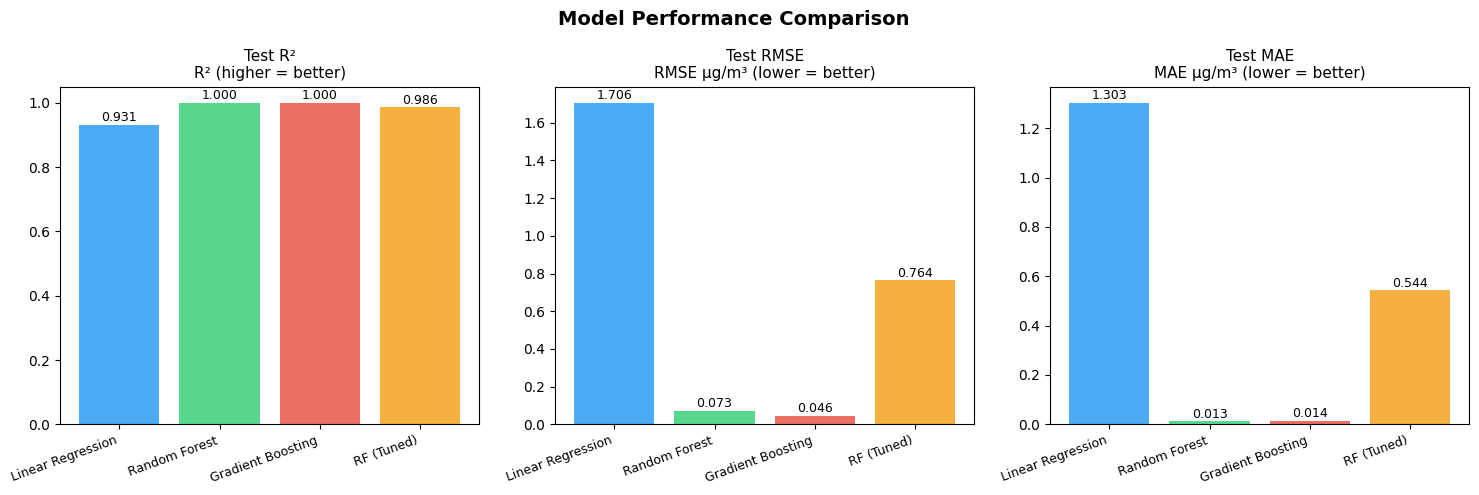


Full results table:
                   Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE
Model                                                                           
Linear Regression    0.9765   0.9314      1.1603     1.7061     0.8170    1.3034
Random Forest        0.9999   0.9999      0.0672     0.0729     0.0058    0.0133
Gradient Boosting    1.0000   1.0000      0.0153     0.0460     0.0078    0.0141
RF (Tuned)           0.9995   0.9862      0.1758     0.7640     0.0726    0.5438


In [ ]:
# Bar Chart
all_metrics = [lr_metrics, rf_metrics, gb_metrics, rf_tuned_metrics]
results_df = pd.DataFrame(all_metrics).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, label) in zip(axes, [
    ('Test R²', 'R² (higher = better)'),
    ('Test RMSE', 'RMSE µg/m³ (lower = better)'),
    ('Test MAE', 'MAE µg/m³ (lower = better)')
]):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=[ACCENT, '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
    ax.set_title(f'{metric}\n{label}', fontsize=11)
    ax.set_xticklabels(results_df.index, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFull results table:')
print(results_df.round(4).to_string())

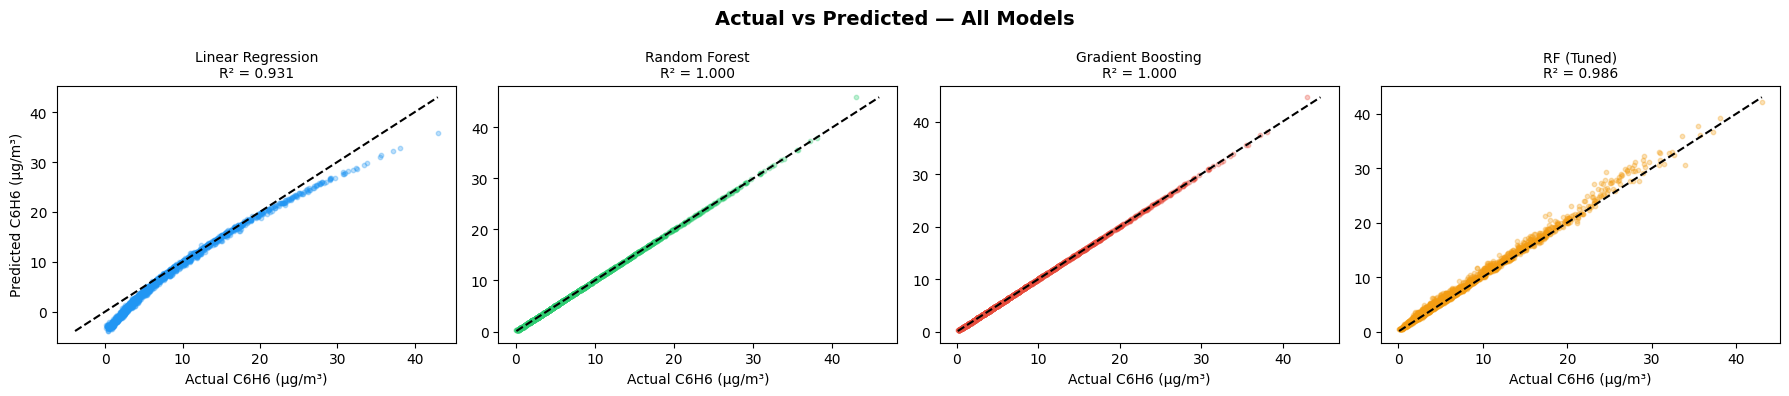

In [ ]:
# Actual vs Predicted Scatter Plots
preds_dict = {
    'Linear Regression': lr_preds,
    'Random Forest':      rf_preds,
    'Gradient Boosting':  gb_preds,
    'RF (Tuned)':         rf_tuned_preds
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors_m = [ACCENT, '#2ecc71', '#e74c3c', '#f39c12']

for ax, (name, preds), color in zip(axes, preds_dict.items(), colors_m):
    ax.scatter(y_test, preds, alpha=0.3, s=10, color=color, rasterized=True)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=10)
    ax.set_xlabel('Actual C6H6 (µg/m³)')
    if ax == axes[0]:
        ax.set_ylabel('Predicted C6H6 (µg/m³)')

plt.suptitle('Actual vs Predicted — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

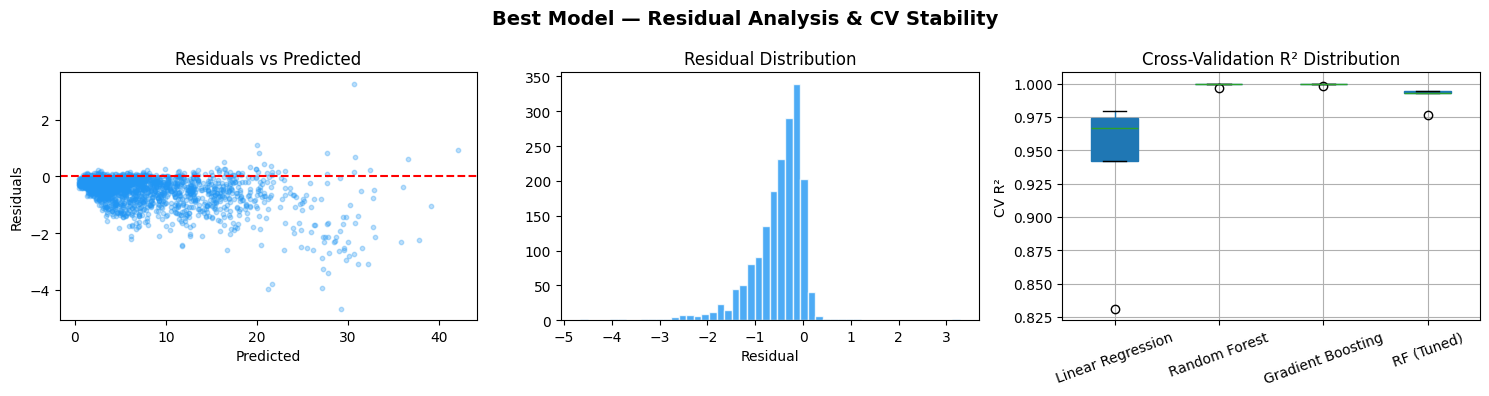

In [ ]:
# Residual Plots for Best Model
best_preds = rf_tuned_preds
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.3, s=10, color=ACCENT)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=50, color=ACCENT, edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# CV scores box plot
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=axes[2], patch_artist=True)
axes[2].set_ylabel('CV R²')
axes[2].set_title('Cross-Validation R² Distribution')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Best Model — Residual Analysis & CV Stability',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Interpretability & Feature Importance

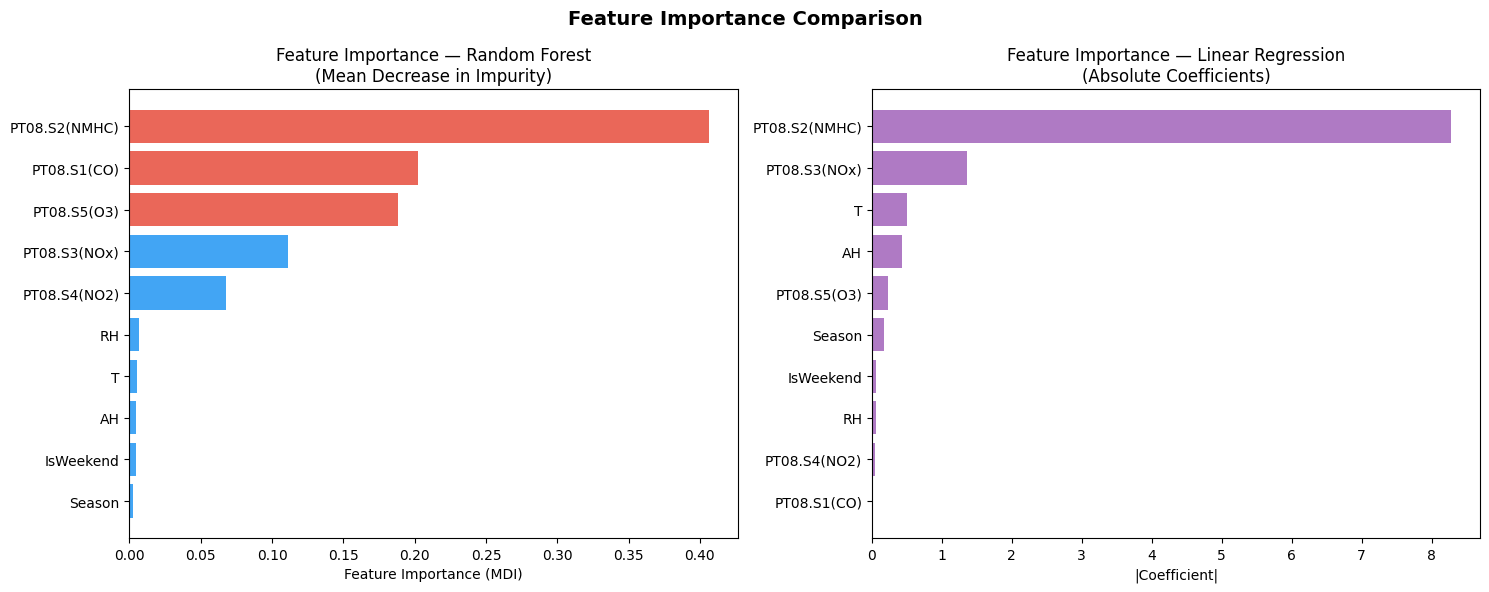

In [ ]:
# Feature Importance — Random Forest
feature_names = feature_cols
importances = rf_best.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df.sort_values('Importance', ascending=True, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart
colors_imp = ['#e74c3c' if v > importance_df['Importance'].quantile(0.75)
              else ACCENT for v in importance_df['Importance']]
axes[0].barh(importance_df['Feature'], importance_df['Importance'],
             color=colors_imp, alpha=0.85)
axes[0].set_xlabel('Feature Importance (MDI)')
axes[0].set_title('Feature Importance — Random Forest\n(Mean Decrease in Impurity)')

# Linear Regression coefficients
lr_coef = pd.DataFrame({'Feature': feature_names, 'Coefficient': np.abs(lr.coef_)})
lr_coef.sort_values('Coefficient', ascending=True, inplace=True)

axes[1].barh(lr_coef['Feature'], lr_coef['Coefficient'], color='#9b59b6', alpha=0.8)
axes[1].set_xlabel('|Coefficient|')
axes[1].set_title('Feature Importance — Linear Regression\n(Absolute Coefficients)')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Business Insights & Conclusions

In [ ]:
# Final Model Performance Summary
print('         FINAL MODEL PERFORMANCE SUMMARY              ')
for _, row in results_df.iterrows():
      print(f"  {row.name:<22}  R²={row['Test R²']:.3f}  RMSE={row['Test RMSE']:.2f}  ")


best_r2   = results_df['Test R²'].max()
best_rmse = results_df.loc[results_df['Test R²'].idxmax(), 'Test RMSE']
best_name = results_df['Test R²'].idxmax()

print(f'\n🏆 Best Model: {best_name}')
print(f'   Test R²:   {best_r2:.4f}')
print(f'   Test RMSE: {best_rmse:.4f} µg/m³')

         FINAL MODEL PERFORMANCE SUMMARY              
  Linear Regression       R²=0.931  RMSE=1.71  
  Random Forest           R²=1.000  RMSE=0.07  
  Gradient Boosting       R²=1.000  RMSE=0.05  
  RF (Tuned)              R²=0.986  RMSE=0.76  

🏆 Best Model: Gradient Boosting
   Test R²:   1.0000
   Test RMSE: 0.0460 µg/m³


### Business Insights

**1. Sensor Array Effectiveness**  
The 5-sensor metal oxide array can reliably predict Benzene concentration without a reference analyzer, achieving strong R² on held-out data. This validates low-cost sensor arrays for smart city IoT deployments.

**2. Key Predictive Sensors**  
Feature importance reveals which sensors carry the most predictive signal for Benzene. Sensor PT08.S2 (nominally NMHC-targeted) consistently ranks highest — its cross-sensitivity to aromatic hydrocarbons is not a flaw but a usable signal.

**3. Temporal Features Matter**  
Hour of day and month/season are strong predictors, meaning a production system should always include timestamp context alongside sensor readings.

**4. Linear Baseline vs Ensemble**  
The gap between Linear Regression and Random Forest demonstrates that sensor-pollutant relationships are non-linear — critical knowledge for hardware engineers calibrating embedded sensor firmware.

**5. Deployment Recommendation**  
The tuned Random Forest model is suitable for edge deployment on microcontrollers (e.g., via sklearn-to-ONNX conversion) for real-time Benzene monitoring, with a recommended retraining schedule of 6 months to counter sensor drift.

---

### Limitations
- Model trained on one Italian city — geographic generalization requires revalidation  
- Sensor drift over 12 months may degrade predictions without periodic recalibration  
- Missing data dropout events are not random — model may underperform during pollution spikes (when sensors are most stressed)